# CS4100 Final Project  
Team Members: Khushi Khan, Dustin Zhang, Kayla Handley, Koena Gupta

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [105]:
spotify_df = pd.read_csv('../data/cleaned/spotify_master_clean_emotion_labels.csv', low_memory=False)

print(spotify_df.shape)

(109926, 27)


In [106]:
spotify_df.head()

,track_name,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,instrumentalness,...,track_name_clean,artist_name_clean,emotion_joy_excitement,emotion_peaceful_content,emotion_anger_tension,emotion_sadness,emotion_joy_excitement_softmax,emotion_peaceful_content_softmax,emotion_anger_tension_softmax,emotion_sadness_softmax
0,!!!!,0.258,0.440074,0.758032,0.744005,0.109109,0.0593,0.8,0.087785,0.890,...,NaN,alicks,0.187190,0.526346,0.689739,0.847196,0.166903,0.234293,0.275879,0.322925
1,!!!!!!!,0.278,0.000000,0.000000,0.620814,0.669670,0.0000,0.0,0.000000,0.000,...,NaN,billie eilish,0.196576,0.510531,0.733922,0.872148,0.165414,0.226423,0.283099,0.325064
2,"""1955",0.437,0.328034,0.317269,0.776171,0.090591,0.0393,0.6,0.037371,0.901,...,1955,pablo lópez,0.310253,0.399070,0.746295,0.787373,0.190444,0.208133,0.294536,0.306887
3,"""42"" - from sr3mm",0.563,0.520191,0.971888,0.861664,0.108108,0.3240,0.8,0.129400,0.000,...,42 from sr3mm,rae sremmurd,0.459317,0.384672,0.622071,0.569186,0.236913,0.219873,0.278787,0.264427
4,"""99""",0.804,0.383946,0.554217,0.901223,0.111111,0.7140,0.8,0.031366,0.000,...,99,barns courtney,0.760333,0.523551,0.603412,0.245165,0.308515,0.243469,0.263710,0.184307


In [107]:
numeric_spotify_df = spotify_df.select_dtypes(include=['number'])

numeric_spotify_df.head()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,instrumentalness,mode,...,acousticness,popularity,emotion_joy_excitement,emotion_peaceful_content,emotion_anger_tension,emotion_sadness,emotion_joy_excitement_softmax,emotion_peaceful_content_softmax,emotion_anger_tension_softmax,emotion_sadness_softmax
0,0.258,0.440074,0.758032,0.744005,0.109109,0.0593,0.8,0.087785,0.890,0.0,...,0.515060,0.24,0.187190,0.526346,0.689739,0.847196,0.166903,0.234293,0.275879,0.322925
1,0.278,0.000000,0.000000,0.620814,0.669670,0.0000,0.0,0.000000,0.000,1.0,...,0.771084,0.33,0.196576,0.510531,0.733922,0.872148,0.165414,0.226423,0.283099,0.325064
2,0.437,0.328034,0.317269,0.776171,0.090591,0.0393,0.6,0.037371,0.901,1.0,...,0.632530,0.00,0.310253,0.399070,0.746295,0.787373,0.190444,0.208133,0.294536,0.306887
3,0.563,0.520191,0.971888,0.861664,0.108108,0.3240,0.8,0.129400,0.000,1.0,...,0.002761,0.55,0.459317,0.384672,0.622071,0.569186,0.236913,0.219873,0.278787,0.264427
4,0.804,0.383946,0.554217,0.901223,0.111111,0.7140,0.8,0.031366,0.000,1.0,...,0.006004,0.64,0.760333,0.523551,0.603412,0.245165,0.308515,0.243469,0.263710,0.184307


In [108]:
# Targets to predict
y = numeric_spotify_df[['valence', 'energy']].to_numpy()
n_outputs = y.shape[1]

# Features to pass in
X = numeric_spotify_df.drop(columns=['valence', 'energy']).to_numpy()
n_samples, n_features = X.shape

In [109]:
# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [110]:
# Initialize eta, hidden nodes, epochs, and weights
eta = 0.01
hidden_nodes = 10
epochs = 100

# Weights
np.random.seed(42)
W1 = np.random.randn(n_features, hidden_nodes)
W2 = np.random.randn(hidden_nodes, n_outputs)

In [111]:
def relu(x):
    return np.maximum(0, W1.T.dot(x))

def relu_deriv(x):
    return (x > 0).astype(float)

In [112]:
errors = []
for epoch in range(epochs):
    total_error = 0

    dW1 = np.zeros_like(W1)
    dW2 = np.zeros_like(W2)

    for i in range(n_samples):
        x = X[i]
        target = y[i]

        h = relu(x)
        y_pred = h @ W2

        error = y_pred - target
        total_error += np.sum(error**2)

        dW2 += np.outer(h, error)
        delta_hidden = relu_deriv(h) * (W2 @ error)
        dW1 += np.outer(x, delta_hidden)

    dW1 = dW1 / n_samples
    dW2 = dW2 / n_samples
    total_error = total_error / n_samples
    
    W1 = W1 - eta * dW1
    W2 = W2 - eta * dW2

    errors.append(total_error)

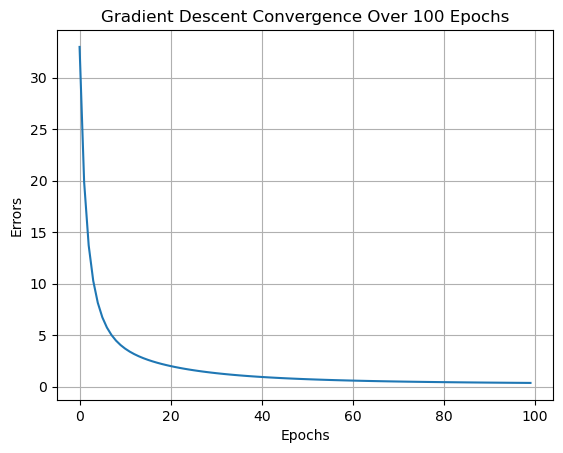

In [113]:
plt.plot(range(epochs), errors, label='line')
plt.title(f"Gradient Descent Convergence Over {epochs} Epochs")
plt.xlabel("Epochs")
plt.ylabel("Errors")
plt.grid(True)
plt.show()

In [114]:
print(f"Final estimate of W(1):\n{W1}\n")
print(f"Final estimate of W(2):\n{W2}")

Final estimate of W(1):
[[ 4.51821126e-01 -3.66557290e-01  5.54339381e-01  1.50627291e+00
  -2.37409359e-01 -3.86456267e-01  1.47621584e+00  6.61629629e-01
  -4.68105167e-01  5.42563438e-01]
 [-5.07801250e-01 -6.81817342e-01  1.01925197e-01 -1.92424024e+00
  -1.72623760e+00 -6.95382014e-01 -1.08842845e+00  1.85606931e-01
  -9.07138701e-01 -1.41230258e+00]
 [ 1.39026458e+00 -5.97703232e-01 -9.33738327e-02 -1.44754939e+00
  -5.51939660e-01 -1.26207575e-01 -1.29871388e+00  2.06328908e-01
  -5.98620381e-01 -2.91656328e-01]
 [-6.25272933e-01  1.73269498e+00 -4.41382198e-02 -1.06249713e+00
   8.13836906e-01 -1.28837192e+00  1.66157693e-01 -1.99008901e+00
  -1.32778320e+00  1.96893111e-01]
 [ 6.68069264e-01 -2.03289440e-01 -2.62313215e-01 -3.23777312e-01
  -1.48294831e+00 -9.69038057e-01 -6.30407617e-01  8.84174401e-01
   3.46444165e-01 -1.76303900e+00]
 [ 3.13191896e-01 -4.31887137e-01 -6.99749297e-01  6.08495522e-01
   1.03038489e+00  9.02302575e-01 -8.52551761e-01 -3.31455337e-01
   3.3149

In [115]:
# Predicting using test data
y_pred = relu(X_test.T).T @ W2

# Rounding the predictions to whole numbers since we're expecting 0's or 1's
y_pred = np.round(y_pred, 0)

In [116]:
y_test.shape

(32978, 2)

In [117]:
y_pred.shape

(32978, 2)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

MSE: 0.3118
MAE: 0.4781
R^2: -3.4406
